# Commute Accessibility and Deutschlandticket Adoption Analysis

The notebook explores how attractive public transport could be for employees commuting to the Johnson & Johnson Medical GmbH site in Norderstedt.

Since real employee addresses are sensitive, I created a synthetic employee dataset for Hamburg, Norderstedt, and nearby surrounding areas. The analysis estimates door-to-door commute time, public transport accessibility, delay sensitivity, and likely Deutschlandticket adoption potential.

The main idea is simple: public transport becomes more attractive when the commute is reasonably fast, easy to access, and not too dependent on multiple transfers.

## What I Built

The project is structured as a small data science pipeline rather than a single script. The main steps are:

1. Create synthetic employee locations
2. Add public transport station reference data
3. Validate the synthetic dataset
4. Estimate door-to-door commute features
5. Add a 15-minute delay buffer to test reliability sensitivity
6. Calculate a Deutschlandticket adoption score
7. Segment commuters into practical groups
8. Export summary tables, charts, an interactive map, and Power BI-ready data

## Factors Used in the Analysis

I focused on three practical factors that strongly influence whether someone would consider public transport:

| Factor | Reason |
|---|---|
| Walking distance to public transport | If the first part of the trip is inconvenient, the full commute becomes less attractive |
| Number of transfers | More transfers usually mean more friction and higher risk of missed connections |
| Delay sensitivity | A commute that is acceptable on paper may become unattractive if a 15-minute delay pushes it into a worse time category |

The analysis keeps the original commute time and delay-adjusted commute time separate. This makes it easier to see which employees are still well connected even after allowing for reliability issues.

## Modeling Decisions

I started with a simple version of the model that used only major public transport stations such as U-Bahn, S-Bahn, AKN, and regional rail stations. After checking the first results, too many employees were classified as having poor station access.

That did not feel realistic for Hamburg and the surrounding HVV area, because many commuters would not walk directly to a major rail station. They would often start with a nearby local stop or a feeder bus connection.

To make the model more realistic, I separated two concepts:

- nearest practical public transport access point
- major station used for the main route

This gives a more realistic first-mile journey:

**Home → local stop → feeder bus if needed → major station → Norderstedt Mitte → workplace**

I also refined the commuter segments so that a moderately long but still feasible commute is not treated the same as a clearly unattractive long commute.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

sns.set_theme(style="whitegrid")

data_dir = PROJECT_ROOT / "data"
outputs_dir = PROJECT_ROOT / "outputs"

processed_file = data_dir / "processed" / "adoption_scoring_output.csv"
powerbi_file = data_dir / "processed" / "powerbi_dashboard_data.csv"
summary_file = outputs_dir / "summary" / "executive_summary.csv"
area_summary_file = outputs_dir / "summary" / "area_connectivity_summary.csv"

df = pd.read_csv(processed_file)
summary_df = pd.read_csv(summary_file)
area_summary_df = pd.read_csv(area_summary_file)

df.head()

,employee_id,home_area,area_type,latitude,longitude,home_to_work_km,major_station_used_for_route,major_station_area,major_station_mode,major_station_lines,...,delay_impact,crosses_45_min_after_delay,commute_time_score,station_access_score,transfer_score,reliability_score,adoption_score,adoption_potential,ml_cluster,commuter_segment
0,EMP0001,Quickborn,suburban,53.751563,9.917675,7.08,Quickborn,Quickborn,AKN,A1,...,No impact,False,8,10,8,20,46,Medium,3,Moderate-potential commuters
1,EMP0002,Hamburg-Wandsbek,urban,53.595413,10.104764,14.23,Wandsbek Markt,Hamburg-Wandsbek,U-Bahn / Bus,"U1, Bus",...,No impact,False,8,25,14,20,67,High,2,Moderate-potential commuters
2,EMP0003,Henstedt-Ulzburg,outer_suburban,53.771968,9.948691,8.16,Henstedt-Ulzburg,Henstedt-Ulzburg,AKN,"A1, A2",...,No impact,False,8,10,8,20,46,Medium,3,Long commute commuters
3,EMP0004,Pinneberg,suburban,53.679197,9.780776,13.65,Pinneberg,Pinneberg,S-Bahn / Regional,"S3, RE",...,No impact,False,8,10,8,20,46,Medium,3,Long commute commuters
4,EMP0005,Norderstedt,near_workplace,53.703351,9.954122,2.01,Norderstedt Mitte,Norderstedt,U-Bahn / AKN,"U1, A2",...,Minor impact,True,28,18,14,10,70,High,0,Delay-sensitive commuters


## Dataset Overview

The final processed dataset contains one row per synthetic employee. Each row includes the employee's generated home area, estimated public transport access, commute time, delay-adjusted commute time, adoption score, and commuter segment.

The employee locations are synthetic, but the commute logic is designed to reflect realistic commuting decisions around Hamburg and Norderstedt.

In [2]:
print(f"Number of synthetic employees: {len(df):,}")
print(f"Number of home areas: {df['home_area'].nunique()}")
print(f"Average base commute time: {df['base_commute_time_min'].mean():.1f} minutes")
print(f"Average delay-adjusted commute time: {df['risk_adjusted_commute_time_min'].mean():.1f} minutes")
print(f"Average adoption score: {df['adoption_score'].mean():.1f}")

Number of synthetic employees: 1,000
Number of home areas: 15
Average base commute time: 67.0 minutes
Average delay-adjusted commute time: 82.0 minutes
Average adoption score: 58.7


## Executive Summary

The table below summarizes the main results requested in the assessment, including commute-time coverage, adoption potential, delay sensitivity, and average commute metrics.

In [3]:
summary_df

,metric,value
0,Total synthetic employees,1000.0
1,Employees within 30 minutes,3.0
2,Employees within 45 minutes,16.0
3,Employees within 60 minutes,33.4
4,Employees over 60 minutes,66.6
5,High or very high adoption potential,31.4
6,Delay-sensitive employees,33.4
7,Employees crossing 45 minutes after delay,13.0
8,Average base commute time,67.0
9,Average delay-adjusted commute time,82.0


## Commute Time Distribution

The first view looks at base commute time before adding the delay buffer. This is the normal estimated door-to-door public transport commute.

In [4]:
commute_order = ["0-30 min", "31-45 min", "46-60 min", "60+ min"]

commute_distribution = (
    df["base_commute_group"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(commute_order)
    .reset_index()
)

commute_distribution.columns = ["commute_group", "percentage"]
commute_distribution

,commute_group,percentage
0,0-30 min,3.0
1,31-45 min,13.0
2,46-60 min,17.4
3,60+ min,66.6


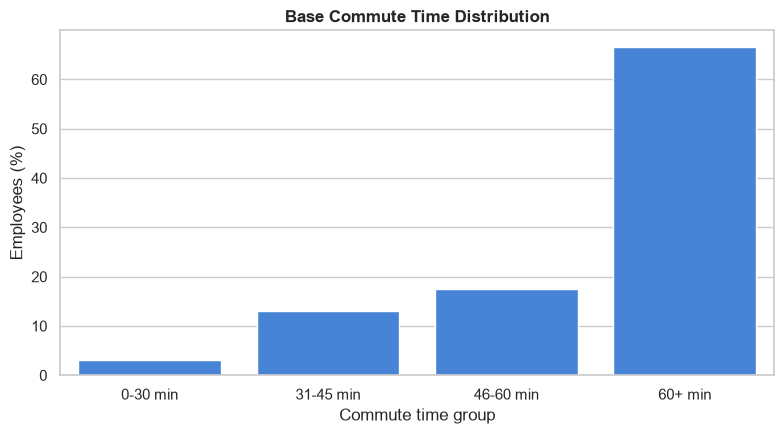

In [5]:
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=commute_distribution,
    x="commute_group",
    y="percentage",
    color="#2F80ED",
)

plt.title("Base Commute Time Distribution", weight="bold")
plt.xlabel("Commute time group")
plt.ylabel("Employees (%)")
plt.tight_layout()
plt.show()

## Delay Sensitivity Analysis

A commute can look acceptable under normal conditions but become less attractive when delays are considered. To capture this, I added a 15-minute reliability buffer as a separate scenario.

This does not replace the original commute time. Instead, it helps identify employees whose commute moves into a worse time category after a realistic delay cushion.

In [6]:
delay_comparison = pd.DataFrame(
    {
        "Base commute": df["base_commute_group"].value_counts(normalize=True).mul(100),
        "Delay-adjusted commute": df["risk_adjusted_commute_group"]
        .value_counts(normalize=True)
        .mul(100),
    }
).reindex(commute_order)

delay_comparison

,Base commute,Delay-adjusted commute
0-30 min,3.0,NaN
31-45 min,13.0,3.0
46-60 min,17.4,13.0
60+ min,66.6,84.0


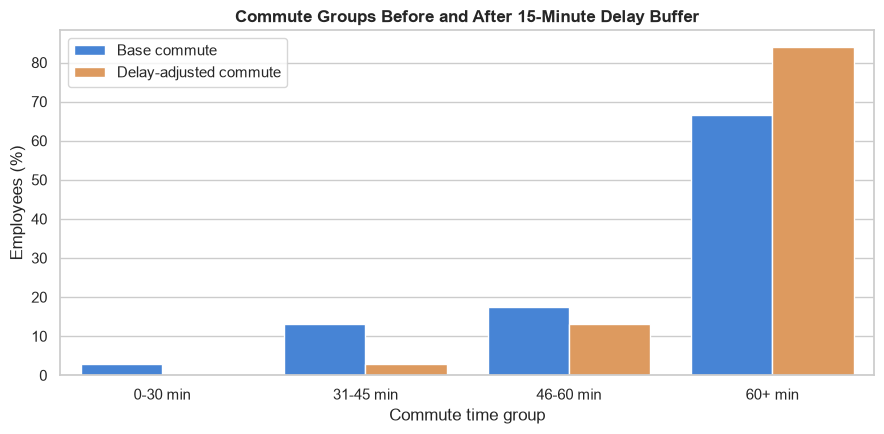

In [7]:
delay_plot_df = delay_comparison.reset_index().melt(
    id_vars="index",
    var_name="scenario",
    value_name="percentage",
)

delay_plot_df = delay_plot_df.rename(columns={"index": "commute_group"})

plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=delay_plot_df,
    x="commute_group",
    y="percentage",
    hue="scenario",
    palette=["#2F80ED", "#F2994A"],
)

plt.title("Commute Groups Before and After 15-Minute Delay Buffer", weight="bold")
plt.xlabel("Commute time group")
plt.ylabel("Employees (%)")
plt.legend(title="")
plt.tight_layout()
plt.show()

The delay impact category shows whether the 15-minute buffer changes the employee's commute group. This is useful for finding commuters who are close to an important threshold, such as 45 or 60 minutes.

In [8]:
delay_impact = (
    df["delay_impact"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

delay_impact.columns = ["delay_impact", "percentage"]
delay_impact

,delay_impact,percentage
0,No impact,66.6
1,Minor impact,33.4


In [9]:
delay_impact = (
    df["delay_impact"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

delay_impact.columns = ["delay_impact", "percentage"]
delay_impact

,delay_impact,percentage
0,No impact,66.6
1,Minor impact,33.4


## Deutschlandticket Adoption Scoring

The adoption score is a transparent rule-based score from 0 to 100. I used a rule-based approach because real adoption labels are not available. This makes the assumptions clear and easy to explain.

The score combines:

- base commute time
- walking distance to public transport
- number of transfers
- delay sensitivity

Higher scores indicate stronger potential for Deutschlandticket adoption.

In [10]:
adoption_order = ["Low", "Medium", "High", "Very High"]

adoption_distribution = (
    df["adoption_potential"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(adoption_order)
    .fillna(0)
    .reset_index()
)

adoption_distribution.columns = ["adoption_potential", "percentage"]
adoption_distribution

,adoption_potential,percentage
0,Low,9.0
1,Medium,59.6
2,High,26.7
3,Very High,4.7


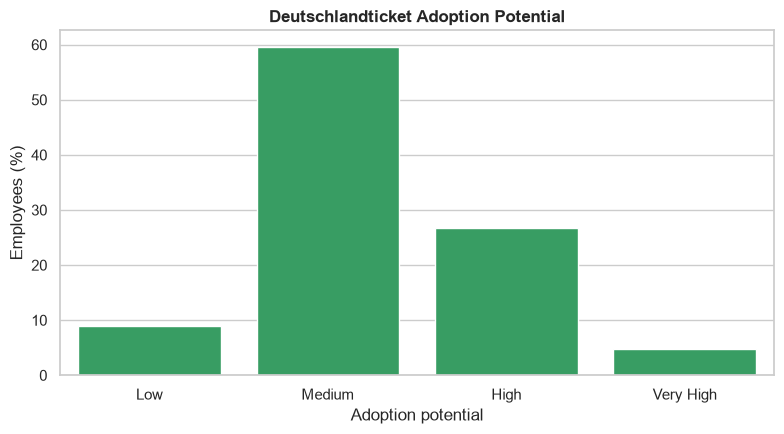

In [12]:
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=adoption_distribution,
    x="adoption_potential",
    y="percentage",
    order=adoption_order,
    color="#27AE60",
)

plt.title("Deutschlandticket Adoption Potential", weight="bold")
plt.xlabel("Adoption potential")
plt.ylabel("Employees (%)")
plt.tight_layout()
plt.show()

## Area-Level Connectivity

The area-level summary helps identify where public transport is most attractive and where it is less competitive. This is useful from a business perspective because communication or mobility support could be targeted by location instead of treating all employees the same.

In [13]:
area_summary_df.head(10)

,home_area,employees,avg_base_commute_min,avg_delay_adjusted_commute_min,avg_public_transport_access_m,avg_transfers,avg_adoption_score,high_or_very_high_potential
0,Norderstedt,176,37.7,52.7,455.3,0.7,76.0,88.1
1,Hamburg-Barmbek,64,61.3,76.3,583.2,0.8,63.3,50.0
2,Hamburg-Wandsbek,98,70.6,85.6,590.0,1.0,62.5,42.9
3,Hamburg-City,95,62.0,77.0,589.7,1.0,62.3,42.1
4,Hamburg-Eimsbuettel,73,61.3,76.3,603.0,1.0,61.7,37.0
5,Hamburg-Altona,81,63.4,78.4,597.0,1.5,58.8,13.6
6,Quickborn,71,63.6,78.6,963.5,1.8,52.9,7.0
7,Pinneberg,63,71.5,86.5,986.1,1.9,50.8,0.0
8,Ahrensburg,53,76.8,91.8,1066.4,1.9,49.5,0.0
9,Henstedt-Ulzburg,53,75.3,90.3,1131.4,1.9,49.1,1.9


The strongest areas are those with shorter commute times, better public transport access, fewer transfers, and higher adoption scores.

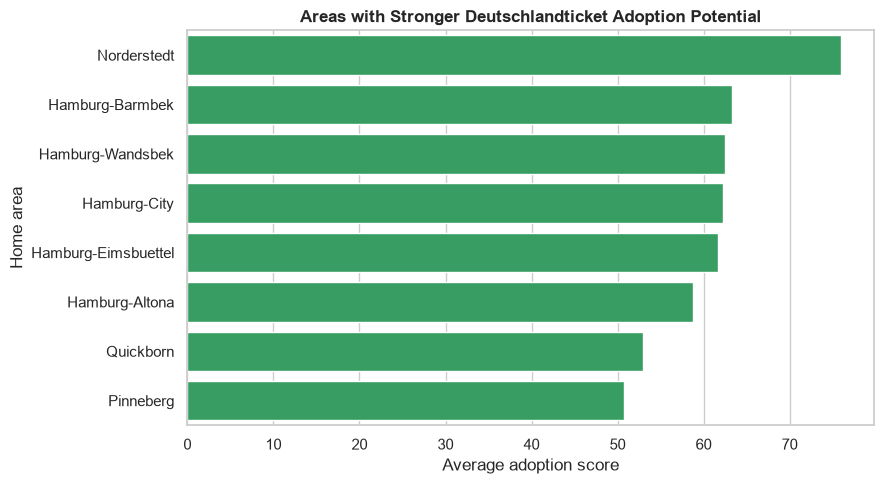

In [14]:
top_areas = area_summary_df.sort_values("avg_adoption_score", ascending=False).head(8)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_areas,
    x="avg_adoption_score",
    y="home_area",
    color="#27AE60",
)

plt.title("Areas with Stronger Deutschlandticket Adoption Potential", weight="bold")
plt.xlabel("Average adoption score")
plt.ylabel("Home area")
plt.tight_layout()
plt.show()

Lower-scoring areas are not necessarily impossible for public transport, but they may require more transfers, longer total travel time, or weaker first-mile access.

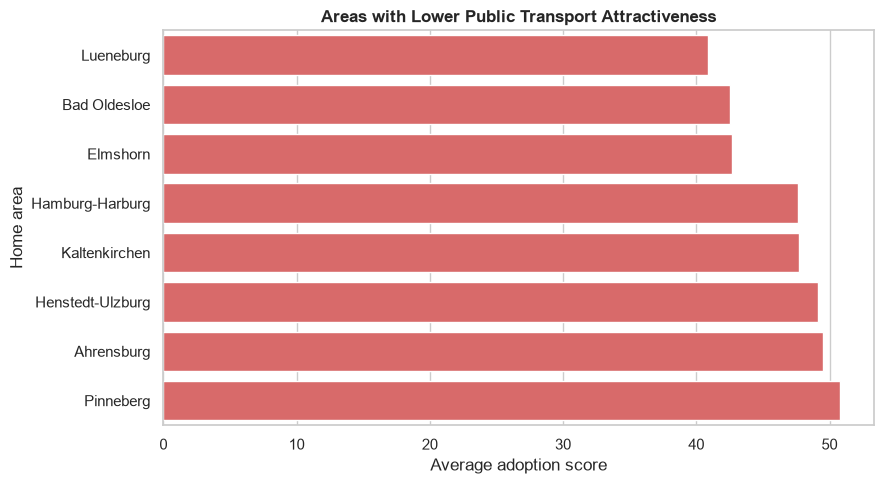

In [15]:
lower_areas = area_summary_df.sort_values("avg_adoption_score", ascending=True).head(8)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=lower_areas,
    x="avg_adoption_score",
    y="home_area",
    color="#EB5757",
)

plt.title("Areas with Lower Public Transport Attractiveness", weight="bold")
plt.xlabel("Average adoption score")
plt.ylabel("Home area")
plt.tight_layout()
plt.show()

## Key Factors Influencing Adoption

To check whether the scoring behaves logically, I looked at the relationship between the input factors and the final adoption score.

A negative correlation means that higher values reduce adoption potential. For example, longer commute time or more transfers should reduce the score. A positive correlation means the factor supports adoption potential.

In [16]:
key_factors_file = outputs_dir / "summary" / "key_factor_correlations.csv"
key_factors_df = pd.read_csv(key_factors_file)

key_factors_df

,factor,correlation_with_adoption_score
0,base_commute_time_min,-0.831
1,risk_adjusted_commute_time_min,-0.831
2,number_of_transfers,-0.821
3,nearest_public_transport_access_m,-0.802
4,station_connectivity_score,0.553


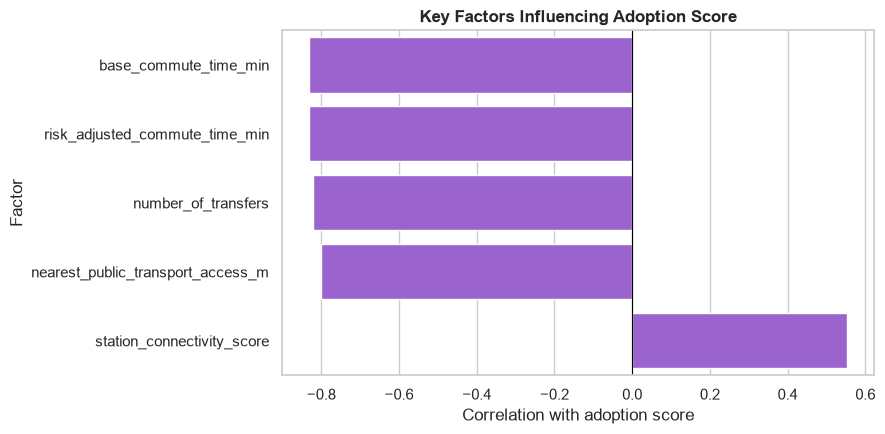

In [18]:
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=key_factors_df,
    x="correlation_with_adoption_score",
    y="factor",
    color="#9B51E0",
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Key Factors Influencing Adoption Score", weight="bold")
plt.xlabel("Correlation with adoption score")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

## ML-Based Commuter Segmentation

Because real Deutschlandticket adoption labels are not available, I did not train a supervised prediction model. Instead, I used clustering as an exploratory machine learning step.

The clustering groups employees based on commute time, delay-adjusted time, public transport access, transfers, connectivity, and adoption score. I then assigned business-friendly segment names so the results are easier to interpret.

In [19]:
segment_distribution = (
    df["commuter_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

segment_distribution.columns = ["commuter_segment", "percentage"]
segment_distribution

,commuter_segment,percentage
0,Moderate-potential commuters,36.8
1,Delay-sensitive commuters,28.7
2,Long commute commuters,25.2
3,High-potential PT users,4.7
4,Poor station access commuters,4.6


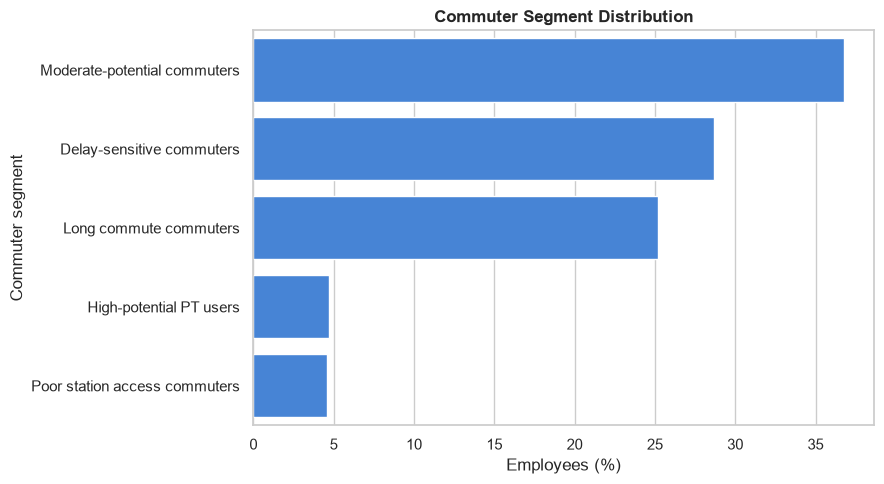

In [20]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=segment_distribution,
    x="percentage",
    y="commuter_segment",
    color="#2F80ED",
)

plt.title("Commuter Segment Distribution", weight="bold")
plt.xlabel("Employees (%)")
plt.ylabel("Commuter segment")
plt.tight_layout()
plt.show()

In [21]:
df.groupby("commuter_segment")[
    [
        "base_commute_time_min",
        "risk_adjusted_commute_time_min",
        "nearest_public_transport_access_m",
        "number_of_transfers",
        "adoption_score",
    ]
].mean().round(1)

,base_commute_time_min,risk_adjusted_commute_time_min,nearest_public_transport_access_m,number_of_transfers,adoption_score
commuter_segment,,,,,
Delay-sensitive commuters,47.8,62.8,551.8,0.8,67.6
High-potential PT users,29.4,44.4,377.9,0.0,87.0
Long commute commuters,88.0,103.0,992.0,2.2,49.3
Moderate-potential commuters,67.8,82.8,707.2,1.5,57.3
Poor station access commuters,103.6,118.6,1813.8,2.5,37.6


## Interactive Map

An interactive Folium map was created to make the spatial results easier to explore. The map includes:

- synthetic employee locations
- workplace location
- major public transport stations
- adoption potential color coding
- commute details in employee popups

The map is saved as:

`outputs/maps/commute_map.html`

In [22]:
map_file = outputs_dir / "maps" / "commute_map.html"

if map_file.exists():
    print(f"Interactive map available at: {map_file}")
else:
    print("Map file not found. Run src/map_visualization.py to generate it.")

Interactive map available at: c:\Users\heysh\downloads\projects\jnj-employee-commute-intelligence\outputs\maps\commute_map.html


## Power BI Export

To support dashboarding, the final scored and segmented dataset was exported as a Power BI-ready CSV file.

This file can be used to build dashboard views such as:

- commute-time distribution
- adoption potential by area
- delay-sensitive commuters
- station access quality
- commuter segments
- map-based employee distribution

In [23]:
print(f"Power BI-ready dataset: {powerbi_file}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Power BI-ready dataset: c:\Users\heysh\downloads\projects\jnj-employee-commute-intelligence\data\processed\powerbi_dashboard_data.csv
Rows: 1,000
Columns: 40


## Final Findings

Based on the synthetic analysis, public transport attractiveness varies strongly by location and commute complexity.

The strongest adoption potential appears in areas with shorter total commute times, good public transport access, and fewer transfers. Employees in these areas are more likely to find the Deutschlandticket attractive.

Delay sensitivity is an important factor. Some employees have a commute that is acceptable under normal conditions, but a 15-minute reliability buffer pushes them into a worse commute category. These employees may still be interested in the Deutschlandticket, but reliability and route planning would matter more for them.

Lower-attractiveness areas are generally affected by longer travel times, weaker first-mile access, or more complicated route structures. These areas may require additional mobility support, such as park-and-ride guidance, bike-to-station options, or flexible working arrangements.

## Recommendations

The results suggest that the Deutschlandticket would not have the same value for every employee group. For employees living in well-connected areas such as Norderstedt or parts of Hamburg with simple routes, the ticket could be promoted as a strong commuting option.

For delay-sensitive commuters, the ticket may still be attractive, but the message should be more careful. These employees are close to important commute-time thresholds, so reliability and realistic travel planning matter more than just the ticket price.

For employees in weaker-connected areas, the analysis should not assume that public transport is automatically practical. These groups may need additional support, such as park-and-ride information, bike-to-station options, or flexible working arrangements.

If this were used in a real company setting, I would treat this as a first screening model. The next step would be to replace synthetic locations with anonymized or aggregated employee location data and improve the commute estimates with official routing data where available.